In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd drive/MyDrive/CS331/ThuongPhuc/Demo1

/content/drive/.shortcut-targets-by-id/1IlgUExhirsyB2WnMMnEhPIkwSvFC8vM6/CS331/ThuongPhuc/Demo1


In [3]:
%ls

 Dataset-FoodSeg103/  'FoodSeg_DeepLabV3(demo).ipynb'


In [4]:
!pwd

/content/drive/.shortcut-targets-by-id/1IlgUExhirsyB2WnMMnEhPIkwSvFC8vM6/CS331/ThuongPhuc/Demo1


In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os
import json
import numpy as np
from PIL import Image
from tqdm import tqdm
import base64
import io
import zlib
from collections import defaultdict

In [6]:
class FoodSegDataset(Dataset):
  def __init__(self, root_dir, target_size=(224,224), split='train', transform=None):
    self.root_dir = root_dir
    self.split = split
    self.transform = transform
    self.img_dir = os.path.join(root_dir, split, 'img')
    self.ann_dir = os.path.join(root_dir, split, 'ann')
    self.images = sorted(os.listdir(self.img_dir))
    self.target_size = target_size

    self.class_mapping = {'background': 0}
    self.reverse_mapping = {0: 'background'}
    self.create_class_mapping()

  def create_class_mapping(self):
    class_ids = set()
    for img_name in self.images:
      ann_name = os.path.splitext(img_name)[0]+'.jpg.json'
      ann_path = os.path.join(self.ann_dir, ann_name)
      with open(ann_path, 'r') as f:
        annotation = json.load(f)

      for obj in annotation['objects']:
        class_ids.add(obj['classId'])

      for idx, classId in enumerate( sorted(class_ids), start=1 ): # excluce background class
        self.class_mapping[classId] = idx
        self.reverse_mapping[idx] = classId
      self.num_classes = len(self.class_mapping) # now 104 with backbround
      #print(f"Total classes including background: {self.num_classes}")

  def decode_bitmap(self,bitmap_data, origin, size):
    try:
      # Remove whitespace and add padding if necessary
      bitmap_data = bitmap_data.strip()
      padding = len( bitmap_data) % 4
      if padding:
        bitmap_data += '=' * (4-padding)

      # Decode base64 data
      decoded_data = base64.b64decode(bitmap_data)

      try:
        decoded_data = zlib.decompress(decoded_data)
      except zlib.error:
        pass

      stream = io.BytesIO(decoded_data)
      bitmap_image = Image.open(stream)
      mask = np.array(bitmap_image)

      if len(mask.shape) == 3:
        mask = mask[:, :, 0]

      full_mask = np.zeros((size['height'], size['width']), dtype=np.int32)

      h, w = mask.shape
      x, y = origin
      x_end = min(x + w, size['width'])
      y_end = min(y + h, size['height'])
      w = x_end - x
      h = y_end - y

      full_mask[y:y+h, x:x+w] = mask[:h, :w]

      return full_mask

    except Exception as e:
      print(f"Error decoding bitmap: {str(e)}")
      return np.zeros((size['height'], size['width']), dtype=np.int32)

  def __getitem__(self, idx):
    try:
      # Load image
      img_name = self.images[idx]
      img_path = os.path.join(self.img_dir, img_name)
      image = Image.open(img_path).convert('RGB')

      # Load annotation
      ann_name = os.path.splitext(img_name)[0]+'.jpg.json'
      ann_path = os.path.join(self.ann_dir, ann_name)

      with open(ann_path, 'r') as f:
        annotation = json.load(f)

      # Create segmentation mask
      mask = np.zeros((annotation['size']['height'], annotation['size']['width']), dtype=np.int32)

      # Fill mask with mapped class labels
      for obj in annotation['objects']:
        original_classId = obj['classId']
        mapped_classId = self.class_mapping[original_classId]
        bitmap_data = obj['bitmap']['data']
        origin = obj['bitmap']['origin']

        obj_mask = self.decode_bitmap(bitmap_data, origin, annotation['size'])
        mask[obj_mask > 0] = mapped_classId

      # Convert mask to PIL Image for resizing
      mask_pil = Image.fromarray(mask.astype(np.uint8))

      # Resize both image and mask to target size
      image = image.resize( self.target_size[::-1], Image.Resampling.BILINEAR ) # reverse order of size
      mask_pil = mask_pil.resize(self.target_size[::-1], Image.Resampling.NEAREST)

      if self.transform:
        image = self.transform(image)

      # Convert mask back to tensor
      mask = torch.from_numpy(np.array(mask_pil)).long()
      return image, mask

    except Exception as e:
      print(f"Error processing item {idx}: {str(e)}")
      dummy_image = torch.zeros((3, *self,target_size))
      dummy_mask = torch.zeros(self.target_size, dtype=torch.long)
      return dummy_image, dummy_mask

  def __len__(self):
    return len(self.images)

In [7]:
def load_image(image_path, transform_fn, target_size=(224, 224)):
  """Load and preprocess an image for inference"""
  image = Image.open(image_path).convert('RGB')
  #image = image.resize(target_size[::-1], Image.Resampling.BILINEAR)
  image = image.resize(target_size, Image.Resampling.BILINEAR)
  image_tensor = transform_fn(image)
  return image_tensor, image

In [8]:
def get_prediction(model, image_tensor, device):
  model.eval()
  with torch.no_grad():
    image_tensor = image_tensor.unsqueeze(0).to(device)
    output = model(image_tensor)
    probabilites = F.softmax(output, dim=1)
    predictions = torch.argmax(probabilites, dim=1)
  return predictions[0].cpu().numpy()

In [9]:
def get_class_names(dataset):
  """Get class names from dataset's revese mapping, including background"""
  class_names= {0:'background'}

  for idx, classId in dataset.reverse_mapping.items():
    if idx==0: # Skip background class
      continue
    for image_name in dataset.images:
      ann_name = os.path.splitext(img_name)[0] + '.jpg.json'
      ann_path = os.path.join(dataset.ann_dir, ann_name)
      with open(ann_path, 'r') as f:
        annotation = json.load(f)

      for obj in annotation['objects']:
        if obj['classId'] == classId:
          class_names[idx] = obj['classTitle']
          break
        if idx in class_names:
          break
  return class_names

In [10]:
def create_colored_mask(prediction, dataset, class_names):
  """Create a colored segmentation mask with class names"""
  # Create colormap with consistent colors
  colors = plt.cm.get_cmap('tab20')(np.linspace(0,1, dataset.num_classes))
  colors = (colors[:, :3]*255).astype(np.uint8) # colors shape: [num_classes, 3]

  # Make background color blue
  colors[0] = [0,0,255] #RGB

  colored_mask = colors[prediction]
  return colored_mask, colors

In [11]:
def overlay_mask(image, colored_mask, alpha = 0.5):
  """Overlay the colored mask on the original image"""
  image_np = np.array(image).astype(np.uint8)
  colored_mask = colored_mask.astype(np.uint8)
  if image_np.shape != colored_mask.shape:
    colored_mask = cv2.resize(colored_mask, (image_np.shape[1], image_np.shape[0]))
  overlay = cv2.addWeighted(image_np, 1-alpha, colored_mask, alpha, 0)
  return overlay

In [12]:
def predict_and_visualize(model ,image_path, dataset, transform_fn, device, save_path=None):
  """Complete pipeline for prediction and visualization with class names"""
  class_names = get_class_names(dataset)
  image_tensor, original_image = load_image(image_path=image_path,transform_fn=transform_fn )
  prediction = get_grediction(model, image_tensor, device)
  colored_mask, colors = create_colored_mask(prediction, dataset, class_names)
  overlay = overlay_mask(original_image, colored_mask)

  fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(20,6))
  ax1.imshow(original_image)
  ax1.set_title('Original Image')
  ax1.axis('off')

  ax2.imshow(colored_mask)
  ax2.set_title('Segmentation Mask')
  ax2.axis('off')

  ax3.imshow(overlay)
  ax3.set_title('Overlay')
  ax3.axis('off')

  # Create legend elements
  legend_elements, legend_lables = [], []
  unique_classes = np.unique(prediction)

  #always include background if it exists in the prediction
  if 0 in unique_classes:
    legend_elements.append( plt.Rectangle((0,0), 1, 1, facecolor=colors[0]/255))
    legend_labels.append('background')

  for class_idx in unique_classes:
    if class_idx != 0 and class_indx in class_names:
      legend_elements.append( plt.Rectangle((0,0), 1, 1, facecolor=colors[class_idx]/255))
      legend_labels.append(class_names[class_idx])

  fig.legend(legend_elements, legend_labels,
              loc='center left',
              bbox_to_anchor=(1.0, 0.5),
              title='Classes Present',
              borderaxespad=0.5,
              labelspacing=1.2)
  plt.tight_layout()

  if save_path:
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
  plt.show()
  return prediction, colored_mask, overlay

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
transform_fn = transforms.Compose([
      transforms.ToTensor(),

      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
  ])

In [15]:
target_sz=(224,224)
train_dataset  = FoodSegDataset(root_dir='Dataset-FoodSeg103',target_size=target_sz, split='train', transform=transform_fn)
val_dataset  = FoodSegDataset(root_dir='Dataset-FoodSeg103',target_size=target_sz, split='train', transform=transform_fn)

batch_sz = 8
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sz, shuffle=True)


In [16]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet50', pretrained=True)
model.classifier[4] = nn.Conv2d(256, train_dataset.num_classes, kernel_size=1)
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10: 100%|██████████| 2/2 [00:01<00:00,  1.14batch/s, loss=2.61]


Epoch 1/10, Training Loss: 2.6506
Validation Loss after epoch 1: 2.4958
Best model saved at epoch 1 with validation loss 2.4958


Epoch 2/10: 100%|██████████| 2/2 [00:01<00:00,  1.28batch/s, loss=2.49]


Epoch 2/10, Training Loss: 2.5612
Validation Loss after epoch 2: 2.3424
Best model saved at epoch 2 with validation loss 2.3424


Epoch 3/10: 100%|██████████| 2/2 [00:01<00:00,  1.29batch/s, loss=2.39]


...

Epoch 8/10, Training Loss: 1.9859
Validation Loss after epoch 8: 1.7418
Best model saved at epoch 8 with validation loss 1.7418


Epoch 9/10: 100%|██████████| 2/2 [00:01<00:00,  1.24batch/s, loss=2.01]


Epoch 9/10, Training Loss: 1.9605
Validation Loss after epoch 9: 1.6870
Best model saved at epoch 9 with validation loss 1.6870


Epoch 10/10: 100%|██████████| 2/2 [00:01<00:00,  1.07batch/s, loss=1.82]


Epoch 10/10, Training Loss: 1.9093
Validation Loss after epoch 10: 1.6400
Best model saved at epoch 10 with validation loss 1.6400


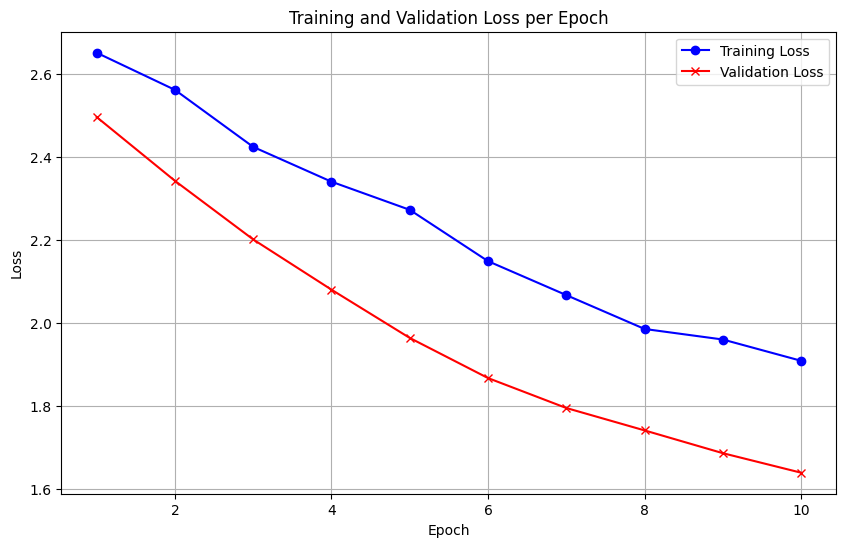

Final checkpoint saved with epoch 10, loss 1.9093, and best validation loss 1.6400


In [18]:
# Training loop
num_epochs = 10
best_loss = float('inf')  # Initialize the best loss to a very high value

train_losses = []
val_losses = []


# Loop over epochs
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    # Wrap the training data loader with tqdm to track progress
    with tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch") as t:
        for images, masks in t:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()  # Zero the gradients
            outputs = model(images)["out"] # Get model outputs
            loss = criterion(outputs, masks)  # Compute loss
            loss.backward()  # Backpropagate the error
            optimizer.step()  # Update the model parameters

            epoch_loss += loss.item()  # Accumulate the loss for the epoch

            # Update the progress bar with the current loss for the batch
            t.set_postfix(loss=loss.item())

    # Calculate the average training loss for the epoch
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)  # Store the training loss

    # Print epoch loss after the completion of each epoch
    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}")


    # Validation to check performance
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for val_images, val_masks in val_loader:  # val_loader is your validation dataset loader
            val_masks = val_masks.long()  # Ensure target masks are of type LongTensor
            val_images, val_masks = val_images.to(device), val_masks.to(device)

            val_outputs = model(val_images)["out"]

            val_loss += criterion(val_outputs, val_masks).item()

        avg_val_loss = val_loss / len(val_loader)  # Average validation loss
        val_losses.append(avg_val_loss)  # Store the validation loss

    print(f"Validation Loss after epoch {epoch + 1}: {avg_val_loss:.4f}")

    # Save the model if it's the best model so far
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")  # Save only the best model
        print(f"Best model saved at epoch {epoch + 1} with validation loss {avg_val_loss:.4f}")


# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue', linestyle='-', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red', linestyle='-', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Save a final checkpoint including the model, epoch, optimizer state, and loss
final_checkpoint = {
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": avg_train_loss,  # Last epoch loss
    "best_loss": best_loss
}

torch.save(final_checkpoint, "final_checkpoint.pth")
print(f"Final checkpoint saved with epoch {num_epochs}, loss {avg_train_loss:.4f}, and best validation loss {best_loss:.4f}")
